## Socratic Synthesizer(Deep Research & Critical Thinking)

- 이름: Socratic Synthesizer (소크라테스식 신서사이저)

- 목적: 사용자의 주장에 대해 편향되지 않은 심층 분석을 제공하고, 비판적 사고를 촉진함.

- 핵심 기능:

    - Support Node: 사용자의 가설을 뒷받침하는 데이터와 논리적 근거를 수집/생성.

    - Socrates Node (Adversarial): 생성된 근거의 허점을 찾고 반대 사례(Counter-arguments)를 제시.

    - Synthesis Node: 양측의 의견을 종합하여 최종적인 다각도 분석 보고서 작성.

- 그래프 구조:
Input -> Research_Support -> Socratic_Critic -> Final_Synthesizer -> End

In [8]:
import operator
from typing import Annotated, TypedDict, List, Union, Literal

from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import ToolNode
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from pydantic import BaseModel, Field


In [9]:
# 1. Define the Schema
class SocraticState(TypedDict):
    user_claim: str
    is_valid: bool
    # Messages list is crucial when using ToolNode to track the conversation flow
    messages: Annotated[List[BaseMessage], operator.add]
    supporting_points: str
    adversarial_critique: str
    final_report: str

# 2. Setup Tools
# Using the prebuilt ToolNode requires the tool to be in a list
search_tool = TavilySearchResults(max_results=3)
tools = [search_tool]
tool_node = ToolNode(tools)

# 3. LLM Setup with Tool Binding
llm = ChatOpenAI(model="gpt-4o", temperature=0)
llm_with_tools = llm.bind_tools(tools)

In [3]:

# 3. Guardrail Schema for Conditional Edge
class ClaimValidation(BaseModel):
    """Plan to determine if the claim is researchable."""
    is_researchable: bool = Field(description="Whether the claim is a specific statement that can be analyzed.")
    reason: str = Field(description="Brief reason for the decision.")


In [10]:
# 4. Nodes
class ClaimValidation(BaseModel):
    is_researchable: bool = Field(description="Is the claim valid and researchable?")

def validator_node(state: SocraticState):
    structured_llm = llm.with_structured_output(ClaimValidation)
    result = structured_llm.invoke([HumanMessage(content=state['user_claim'])])
    return {"is_valid": result.is_researchable}

def researcher_node(state: SocraticState):
    """
    This node now just calls the LLM. 
    If the LLM decides it needs info, it will return a tool_call.
    """
    prompt = f"Find 3 evidence-based pillars supporting: {state['user_claim']}. Use search tools if needed."
    # We pass the history or just the prompt
    response = llm_with_tools.invoke([HumanMessage(content=prompt)])
    return {"messages": [response]}

def socratic_node(state: SocraticState):
    # Logic to extract the last message content for the critique
    last_message = state["messages"][-1].content
    prompt = f"Critique this evidence for the claim '{state['user_claim']}': {last_message}"
    response = llm.invoke(prompt)
    return {"adversarial_critique": response.content, "supporting_points": last_message}

def synthesis_node(state: SocraticState):
    prompt = f"Synthesize: \nClaim: {state['user_claim']}\nSupport: {state['supporting_points']}\nCritique: {state['adversarial_critique']}"
    response = llm.invoke(prompt)
    return {"final_report": response.content}

In [11]:
# 5. Conditional Routing Logic
def route_validator(state: SocraticState):
    return "researcher" if state["is_valid"] else "end"

def should_continue(state: SocraticState) -> Literal["tools", "socrates"]:
    """
    Standard pattern: check if the last AI message has tool_calls.
    """
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tools"
    return "socrates"

In [12]:
# 6. Build the Graph
workflow = StateGraph(SocraticState)

workflow.add_node("validator", validator_node)
workflow.add_node("researcher", researcher_node)
workflow.add_node("tools", tool_node)  # The ToolNode
workflow.add_node("socrates", socratic_node)
workflow.add_node("integrator", synthesis_node)

workflow.add_edge(START, "validator")

workflow.add_conditional_edges("validator", route_validator, {
    "researcher": "researcher",
    "end": END
})

# After researcher calls LLM, we check if we need to run ToolNode or move to Socrates
workflow.add_conditional_edges("researcher", should_continue)

# After ToolNode finishes, it MUST go back to the researcher node 
# so the LLM can see the tool output and decide if it's done.
workflow.add_edge("tools", "researcher")

workflow.add_edge("socrates", "integrator")
workflow.add_edge("integrator", END)

app = workflow.compile()

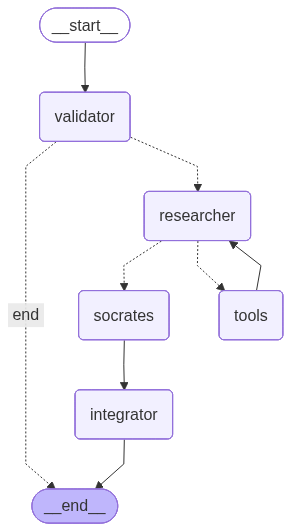

In [13]:
app